In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/AI Comupte CaseStudy"
shipments_path = os.path.join(base_path, "DataCoSupplyChainDataset.csv")
fuel_path = os.path.join(base_path, "fuel.csv")

In [3]:
!pip install -q pyspark

In [4]:
import builtins
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, avg, count, when, to_timestamp, date_format
from pyspark.sql.functions import round as rnd
from pyspark.sql.functions import sum as spark_sum

from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

In [5]:
spark = SparkSession.builder \
    .appName("logistics") \
    .master("local[*]") \
    .config("spark.sql.adaptive.enabled", "true") \
    .getOrCreate()

sc = spark.sparkContext

print("spark version:", spark.version)
print("app name:", sc.appName)
print("master:", sc.master)

spark version: 4.0.3
app name: logistics
master: local[*]


In [6]:
df = spark.read.option("header", True).option("inferSchema", True).csv(shipments_path)
fuel = spark.read.option("header", True).option("inferSchema", True).csv(fuel_path)

print("shipment rows:", df.count())
print("shipment columns:", len(df.columns))
print("fuel rows:", fuel.count())
print("fuel columns:", len(fuel.columns))

shipment rows: 180519
shipment columns: 53
fuel rows: 1067
fuel columns: 13


In [7]:
df.printSchema()

root
 |-- Type: string (nullable = true)
 |-- Days for shipping (real): integer (nullable = true)
 |-- Days for shipment (scheduled): integer (nullable = true)
 |-- Benefit per order: double (nullable = true)
 |-- Sales per customer: double (nullable = true)
 |-- Delivery Status: string (nullable = true)
 |-- Late_delivery_risk: integer (nullable = true)
 |-- Category Id: integer (nullable = true)
 |-- Category Name: string (nullable = true)
 |-- Customer City: string (nullable = true)
 |-- Customer Country: string (nullable = true)
 |-- Customer Email: string (nullable = true)
 |-- Customer Fname: string (nullable = true)
 |-- Customer Id: integer (nullable = true)
 |-- Customer Lname: string (nullable = true)
 |-- Customer Password: string (nullable = true)
 |-- Customer Segment: string (nullable = true)
 |-- Customer State: string (nullable = true)
 |-- Customer Street: string (nullable = true)
 |-- Customer Zipcode: integer (nullable = true)
 |-- Department Id: integer (nullable = 

In [8]:
fuel.printSchema()

root
 |-- MODELYEAR: integer (nullable = true)
 |-- MAKE: string (nullable = true)
 |-- MODEL: string (nullable = true)
 |-- VEHICLECLASS: string (nullable = true)
 |-- ENGINESIZE: double (nullable = true)
 |-- CYLINDERS: integer (nullable = true)
 |-- TRANSMISSION: string (nullable = true)
 |-- FUELTYPE: string (nullable = true)
 |-- FUELCONSUMPTION_CITY: double (nullable = true)
 |-- FUELCONSUMPTION_HWY: double (nullable = true)
 |-- FUELCONSUMPTION_COMB: double (nullable = true)
 |-- FUELCONSUMPTION_COMB_MPG: integer (nullable = true)
 |-- CO2EMISSIONS: integer (nullable = true)



In [9]:
df.select(
    "Order Id",
    "Delivery Status",
    "Late_delivery_risk",
    "Shipping Mode",
    "Department Name",
    "Order Region",
    "Sales"
).show(5, False)

fuel.show(5, False)

+--------+----------------+------------------+--------------+---------------+--------------+------+
|Order Id|Delivery Status |Late_delivery_risk|Shipping Mode |Department Name|Order Region  |Sales |
+--------+----------------+------------------+--------------+---------------+--------------+------+
|77202   |Advance shipping|0                 |Standard Class|Fitness        |Southeast Asia|327.75|
|75939   |Late delivery   |1                 |Standard Class|Fitness        |South Asia    |327.75|
|75938   |Shipping on time|0                 |Standard Class|Fitness        |South Asia    |327.75|
|75937   |Advance shipping|0                 |Standard Class|Fitness        |Oceania       |327.75|
|75936   |Advance shipping|0                 |Standard Class|Fitness        |Oceania       |327.75|
+--------+----------------+------------------+--------------+---------------+--------------+------+
only showing top 5 rows
+---------+-----+----------+------------+----------+---------+------------+-

In [10]:
df = df.withColumn(
    "order_ts",
    to_timestamp(col("order date (DateOrders)"), "M/d/yyyy H:mm")
).withColumn(
    "ship_ts",
    to_timestamp(col("shipping date (DateOrders)"), "M/d/yyyy H:mm")
)

df.createOrReplaceTempView("shipments")
fuel.createOrReplaceTempView("fuel")

print("views ready")

views ready


## Q2. RDD implementation

In [11]:
rdd = df.rdd

mapped = rdd.map(lambda x: (x["Shipping Mode"], x["Late_delivery_risk"], x["Sales"]))
late = mapped.filter(lambda x: x[1] == 1)
mode_pairs = rdd.map(lambda x: (x["Shipping Mode"], 1))
flat = mode_pairs.flatMap(lambda x: [(x[0], x[1]), (x[0] + "_total", 1)])
sales_mode = mapped.map(lambda x: (x[0], x[2])).reduceByKey(lambda a, b: a + b)

total_rows = rdd.count()
late_rows = late.count()
top_modes = sales_mode.sortBy(lambda x: x[1], ascending=False).take(5)
flat_sample = flat.take(10)

print("total rows:", total_rows)
print("late rows:", late_rows)
print("top modes by sales:", top_modes)
print("flat sample:", flat_sample[:5])

total rows: 180519
late rows: 98977
top modes by sales: [('Standard Class', 22022391.87980958), ('Second Class', 7145444.818358989), ('First Class', 5674369.7582026925), ('Same Day', 1942528.557009093)]
flat sample: [('Standard Class', 1), ('Standard Class_total', 1), ('Standard Class', 1), ('Standard Class_total', 1), ('Standard Class', 1)]


## Q3. Key-value operations, shuffle, and persistence

In [12]:
kv_mode = rdd.map(lambda x: (x["Shipping Mode"], x["Late_delivery_risk"]))
kv_dept = rdd.map(lambda x: (x["Department Name"], x["Sales"]))
kv_region = rdd.map(lambda x: (x["Order Region"], 1))

grouped_mode = kv_mode.groupByKey().mapValues(list)
mode_late = grouped_mode.mapValues(lambda x: (builtins.sum(x), len(x), round(builtins.sum(x) * 100 / len(x), 2)))

dept_sales = kv_dept.reduceByKey(lambda a, b: a + b)
region_sorted = kv_region.reduceByKey(lambda a, b: a + b).sortByKey()

dept_sales.persist()
region_sorted.persist()

print("groupByKey summary:")
print(mode_late.take(5))

print("\ntop departments by sales:")
print(dept_sales.sortBy(lambda x: x[1], ascending=False).take(5))

print("\nregions sorted:")
print(region_sorted.take(5))

groupByKey summary:
[('First Class', (26513, 27814, 95.32)), ('Standard Class', (41023, 107752, 38.07)), ('Second Class', (26987, 35216, 76.63)), ('Same Day', (4454, 9737, 45.74))]

top departments by sales:
[('Fan Shop', 17113870.940008044), ('Apparel', 7976255.341231948), ('Golf', 4609028.242088006), ('Footwear', 4006498.7676899536), ('Outdoors', 1253351.4498354734)]

regions sorted:
[('Canada', 959), ('Caribbean', 8318), ('Central Africa', 1677), ('Central America', 28341), ('Central Asia', 553)]


## Q4. DataFrame operations

In [13]:
late_df = df.filter(col("Late_delivery_risk") == 1)

mode_stats = df.groupBy("Shipping Mode").agg(
    count("*").alias("order_count"),
    rnd(avg("Sales"), 2).alias("avg_sales"),
    rnd(spark_sum("Sales"), 2).alias("total_sales"),
    rnd(avg("Days for shipping (real)"), 2).alias("avg_real_days")
)

dept_avg = df.groupBy("Department Name").agg(
    rnd(avg("Sales"), 2).alias("dept_avg_sales")
)

joined_df = df.join(dept_avg, "Department Name", "left")

print("late delivery rows:", late_df.count())

print("\nshipping mode stats:")
mode_stats.show()

print("\njoined sample:")
joined_df.select(
    "Department Name",
    "Sales",
    "dept_avg_sales",
    "Shipping Mode",
    "Late_delivery_risk"
).show(5)

late delivery rows: 98977

shipping mode stats:
+--------------+-----------+---------+-------------+-------------+
| Shipping Mode|order_count|avg_sales|  total_sales|avg_real_days|
+--------------+-----------+---------+-------------+-------------+
|   First Class|      27814|   204.01|   5674369.76|          2.0|
|      Same Day|       9737|    199.5|   1942528.56|         0.48|
|  Second Class|      35216|    202.9|   7145444.82|         3.99|
|Standard Class|     107752|   204.38|2.202239188E7|          4.0|
+--------------+-----------+---------+-------------+-------------+


joined sample:
+---------------+------+--------------+--------------+------------------+
|Department Name| Sales|dept_avg_sales| Shipping Mode|Late_delivery_risk|
+---------------+------+--------------+--------------+------------------+
|        Fitness|327.75|        160.17|Standard Class|                 0|
|        Fitness|327.75|        160.17|Standard Class|                 1|
|        Fitness|327.75|     

## Q5. EDA and Spark SQL

In [14]:
delivery_perf = spark.sql("""
SELECT
    `Delivery Status`,
    COUNT(*) AS order_count,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM shipments), 2) AS order_pct,
    ROUND(AVG(`Days for shipping (real)`), 2) AS avg_real_days,
    ROUND(AVG(`Days for shipment (scheduled)`), 2) AS avg_scheduled_days,
    ROUND(SUM(Sales), 2) AS total_sales
FROM shipments
GROUP BY `Delivery Status`
ORDER BY order_count DESC
""")

delivery_perf.show()

+-----------------+-----------+---------+-------------+------------------+-------------+
|  Delivery Status|order_count|order_pct|avg_real_days|avg_scheduled_days|  total_sales|
+-----------------+-----------+---------+-------------+------------------+-------------+
|    Late delivery|      98977|    54.83|         4.09|              2.47|2.012639527E7|
| Advance shipping|      41592|    23.04|          2.5|               4.0|   8518007.89|
| Shipping on time|      32196|    17.84|         2.98|              2.98|    6570026.5|
|Shipping canceled|       7754|     4.30|         3.48|               2.9|   1570305.36|
+-----------------+-----------+---------+-------------+------------------+-------------+



In [15]:
warehouse_util = spark.sql("""
SELECT
    `Department Name`,
    COUNT(*) AS order_count,
    SUM(`Order Item Quantity`) AS total_quantity,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(AVG(Sales), 2) AS avg_sales,
    SUM(CASE WHEN `Late_delivery_risk` = 1 THEN 1 ELSE 0 END) AS late_orders,
    ROUND(SUM(CASE WHEN `Late_delivery_risk` = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS late_pct
FROM shipments
GROUP BY `Department Name`
ORDER BY total_quantity DESC
""")

warehouse_util.show(20, False)

+------------------+-----------+--------------+-------------+---------+-----------+--------+
|Department Name   |order_count|total_quantity|total_sales  |avg_sales|late_orders|late_pct|
+------------------+-----------+--------------+-------------+---------+-----------+--------+
|Fan Shop          |66861      |106165        |1.711387094E7|255.96   |36623      |54.77   |
|Golf              |33220      |99297         |4609028.24   |138.74   |18198      |54.78   |
|Apparel           |48998      |98181         |7976255.34   |162.79   |26825      |54.75   |
|Footwear          |14525      |43400         |4006498.77   |275.83   |7949       |54.73   |
|Outdoors          |9686       |26059         |1253351.45   |129.4    |5375       |55.49   |
|Fitness           |2479       |6227          |397050.89    |160.17   |1377       |55.55   |
|Discs Shop        |2026       |2026          |228887.73    |112.98   |1103       |54.44   |
|Technology        |1465       |1465          |1039598.97   |709.62   

In [16]:
delayed_mode = spark.sql("""
SELECT
    `Shipping Mode`,
    COUNT(*) AS delayed_count,
    ROUND(AVG(`Days for shipping (real)`), 2) AS avg_real_days,
    ROUND(AVG(`Days for shipment (scheduled)`), 2) AS avg_scheduled_days,
    ROUND(SUM(Sales), 2) AS delayed_sales
FROM shipments
WHERE `Late_delivery_risk` = 1
GROUP BY `Shipping Mode`
ORDER BY delayed_count DESC
""")

delayed_region = spark.sql("""
SELECT
    `Order Region`,
    COUNT(*) AS delayed_count,
    ROUND(SUM(Sales), 2) AS delayed_sales,
    ROUND(AVG(`Days for shipping (real)`), 2) AS avg_real_days
FROM shipments
WHERE `Late_delivery_risk` = 1
GROUP BY `Order Region`
ORDER BY delayed_count DESC
""")

print("delayed by mode:")
delayed_mode.show()

print("delayed by region:")
delayed_region.show(10, False)

delayed by mode:
+--------------+-------------+-------------+------------------+-------------+
| Shipping Mode|delayed_count|avg_real_days|avg_scheduled_days|delayed_sales|
+--------------+-------------+-------------+------------------+-------------+
|Standard Class|        41023|         5.51|               4.0|   8364603.38|
|  Second Class|        26987|          4.5|               2.0|   5477446.44|
|   First Class|        26513|          2.0|               1.0|   5408068.56|
|      Same Day|         4454|          1.0|               0.0|    876276.89|
+--------------+-------------+-------------+------------------+-------------+

delayed by region:
+---------------+-------------+-------------+-------------+
|Order Region   |delayed_count|delayed_sales|avg_real_days|
+---------------+-------------+-------------+-------------+
|Central America|15518        |3110260.23   |4.11         |
|Western Europe |15140        |3292013.64   |4.07         |
|South America  |8111         |1606545.

In [17]:
fuel_class = spark.sql("""
SELECT
    VEHICLECLASS,
    COUNT(*) AS vehicle_count,
    ROUND(AVG(FUELCONSUMPTION_COMB), 2) AS avg_fuel_comb,
    ROUND(AVG(FUELCONSUMPTION_COMB_MPG), 2) AS avg_mpg,
    ROUND(AVG(CO2EMISSIONS), 2) AS avg_co2
FROM fuel
GROUP BY VEHICLECLASS
ORDER BY avg_fuel_comb DESC
""")

fuel_make = spark.sql("""
SELECT
    MAKE,
    COUNT(*) AS vehicle_count,
    ROUND(AVG(FUELCONSUMPTION_COMB), 2) AS avg_fuel_comb,
    ROUND(AVG(CO2EMISSIONS), 2) AS avg_co2
FROM fuel
GROUP BY MAKE
ORDER BY avg_fuel_comb DESC
LIMIT 10
""")

print("fuel by class:")
fuel_class.show(20, False)

print("fuel by make:")
fuel_make.show(10, False)

fuel by class:
+------------------------+-------------+-------------+-------+-------+
|VEHICLECLASS            |vehicle_count|avg_fuel_comb|avg_mpg|avg_co2|
+------------------------+-------------+-------------+-------+-------+
|VAN - PASSENGER         |25           |20.33        |14.2   |401.0  |
|VAN - CARGO             |22           |18.72        |15.41  |361.5  |
|PICKUP TRUCK - STANDARD |62           |14.96        |19.35  |309.1  |
|SUV - STANDARD          |110          |14.53        |20.28  |307.67 |
|MINIVAN                 |14           |12.39        |23.57  |260.14 |
|PICKUP TRUCK - SMALL    |12           |12.36        |23.17  |284.25 |
|FULL-SIZE               |86           |12.16        |24.02  |267.65 |
|TWO-SEATER              |71           |11.55        |26.56  |265.68 |
|SUBCOMPACT              |65           |10.98        |27.09  |252.62 |
|SUV - SMALL             |154          |10.7         |27.03  |242.69 |
|STATION WAGON - MID-SIZE|6            |10.25        |30.17  |

In [18]:
region_report = spark.sql("""
SELECT
    `Order Region`,
    COUNT(*) AS shipment_count,
    ROUND(SUM(Sales), 2) AS total_sales,
    ROUND(AVG(Sales), 2) AS avg_sales,
    ROUND(AVG(`Days for shipping (real)`), 2) AS avg_real_days,
    ROUND(AVG(`Days for shipment (scheduled)`), 2) AS avg_scheduled_days,
    SUM(CASE WHEN `Late_delivery_risk` = 1 THEN 1 ELSE 0 END) AS late_count,
    ROUND(SUM(CASE WHEN `Late_delivery_risk` = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS late_pct
FROM shipments
GROUP BY `Order Region`
ORDER BY total_sales DESC
""")

region_report.show(20, False)

+---------------+--------------+-----------+---------+-------------+------------------+----------+--------+
|Order Region   |shipment_count|total_sales|avg_sales|avg_real_days|avg_scheduled_days|late_count|late_pct|
+---------------+--------------+-----------+---------+-------------+------------------+----------+--------+
|Western Europe |27109         |5894380.77 |217.43   |3.5          |2.9               |15140     |55.85   |
|Central America|28341         |5665712.1  |199.91   |3.51         |2.95              |15518     |54.75   |
|South America  |14935         |2960881.41 |198.25   |3.51         |2.95              |8111      |54.31   |
|Northern Europe|9792          |2155830.65 |220.16   |3.5          |2.96              |5292      |54.04   |
|Southern Europe|9431          |2047918.82 |217.15   |3.44         |2.92              |5129      |54.38   |
|Oceania        |10148         |2016654.2  |198.72   |3.5          |2.94              |5482      |54.02   |
|Southeast Asia |9539       

In [19]:
monthly = spark.sql("""
SELECT
    date_format(order_ts, 'yyyy-MM') AS month,
    COUNT(*) AS shipment_count,
    SUM(CASE WHEN `Late_delivery_risk` = 1 THEN 1 ELSE 0 END) AS late_count,
    ROUND(SUM(Sales), 2) AS total_sales
FROM shipments
WHERE order_ts IS NOT NULL
GROUP BY date_format(order_ts, 'yyyy-MM')
ORDER BY month
""")

monthly.show(20, False)

+-------+--------------+----------+-----------+
|month  |shipment_count|late_count|total_sales|
+-------+--------------+----------+-----------+
|2015-01|5322          |2880      |1051590.08 |
|2015-02|4729          |2594      |927009.9   |
|2015-03|5362          |2936      |1051253.69 |
|2015-04|5126          |2760      |1014463.28 |
|2015-05|5357          |2951      |1050478.44 |
|2015-06|5134          |2778      |1024006.17 |
|2015-07|5299          |2939      |1038081.19 |
|2015-08|5273          |2936      |1029494.69 |
|2015-09|5140          |2914      |1018338.6  |
|2015-10|5302          |2906      |1049154.27 |
|2015-11|5235          |2841      |1029120.24 |
|2015-12|5371          |2937      |1057840.88 |
|2016-01|5317          |2955      |1046308.25 |
|2016-02|4894          |2650      |968542.85  |
|2016-03|5210          |2905      |1025853.12 |
|2016-04|5097          |2815      |1001211.58 |
|2016-05|5302          |2951      |1029400.2  |
|2016-06|5054          |2873      |10030

## Plots

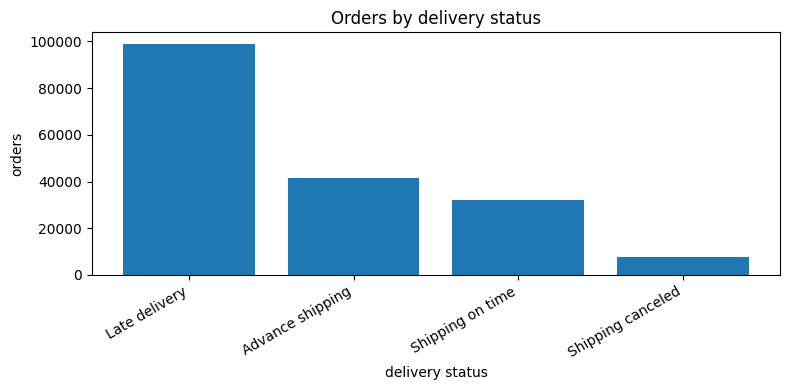

In [20]:
p = delivery_perf.toPandas()

plt.figure(figsize=(8, 4))
plt.bar(p["Delivery Status"], p["order_count"])
plt.title("Orders by delivery status")
plt.xlabel("delivery status")
plt.ylabel("orders")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

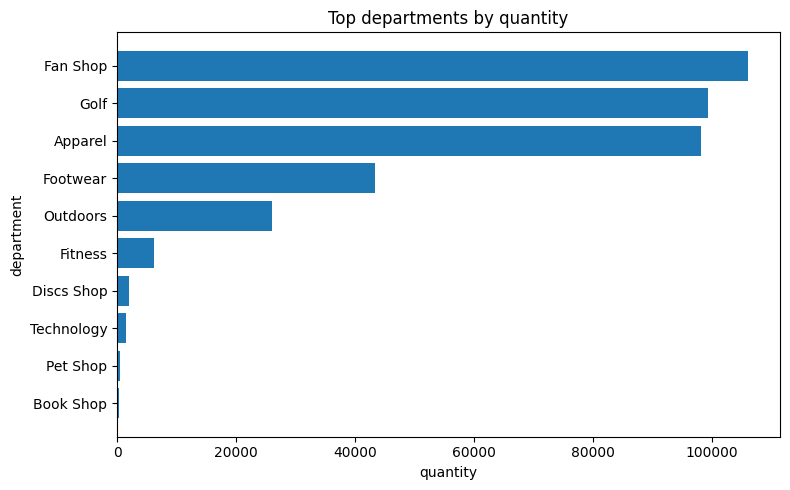

In [21]:
p = warehouse_util.limit(10).toPandas().sort_values("total_quantity")

plt.figure(figsize=(8, 5))
plt.barh(p["Department Name"], p["total_quantity"])
plt.title("Top departments by quantity")
plt.xlabel("quantity")
plt.ylabel("department")
plt.tight_layout()
plt.show()

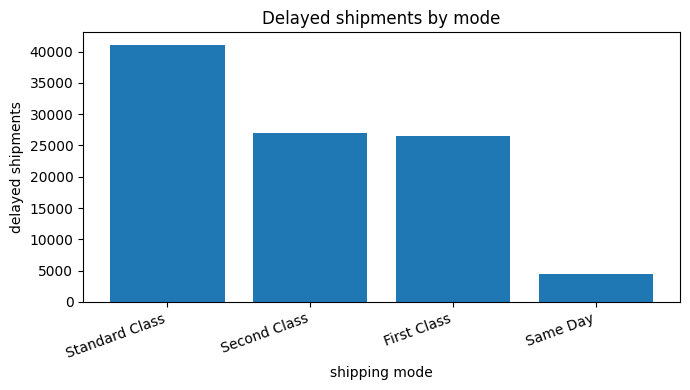

In [22]:
p = delayed_mode.toPandas()

plt.figure(figsize=(7, 4))
plt.bar(p["Shipping Mode"], p["delayed_count"])
plt.title("Delayed shipments by mode")
plt.xlabel("shipping mode")
plt.ylabel("delayed shipments")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

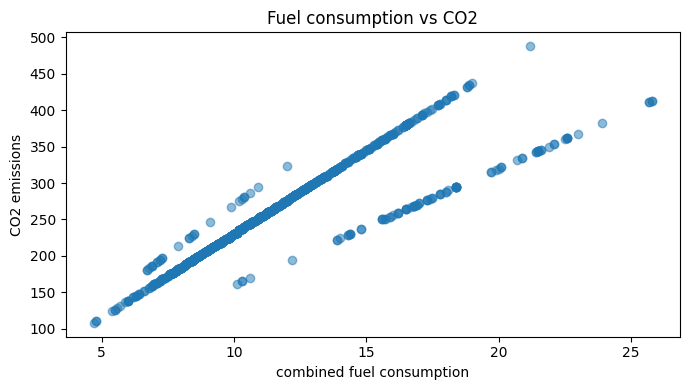

In [23]:
p = fuel.select("FUELCONSUMPTION_COMB", "CO2EMISSIONS").dropna().toPandas()

plt.figure(figsize=(7, 4))
plt.scatter(p["FUELCONSUMPTION_COMB"], p["CO2EMISSIONS"], alpha=0.5)
plt.title("Fuel consumption vs CO2")
plt.xlabel("combined fuel consumption")
plt.ylabel("CO2 emissions")
plt.tight_layout()
plt.show()

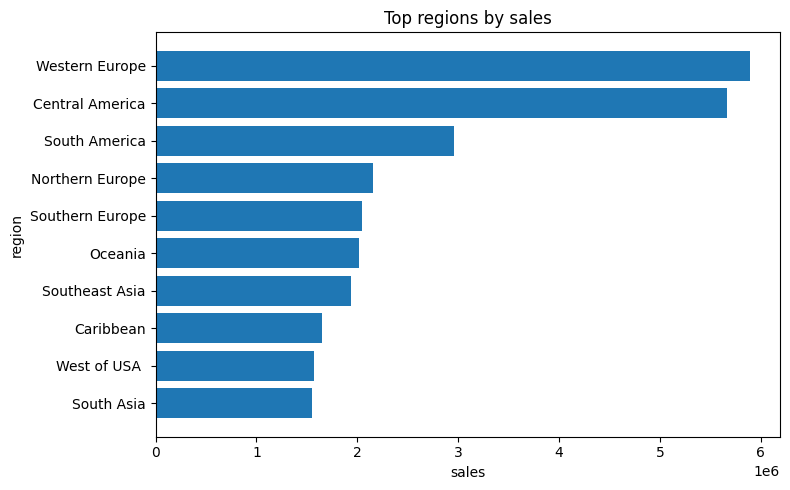

In [24]:
p = region_report.limit(10).toPandas().sort_values("total_sales")

plt.figure(figsize=(8, 5))
plt.barh(p["Order Region"], p["total_sales"])
plt.title("Top regions by sales")
plt.xlabel("sales")
plt.ylabel("region")
plt.tight_layout()
plt.show()

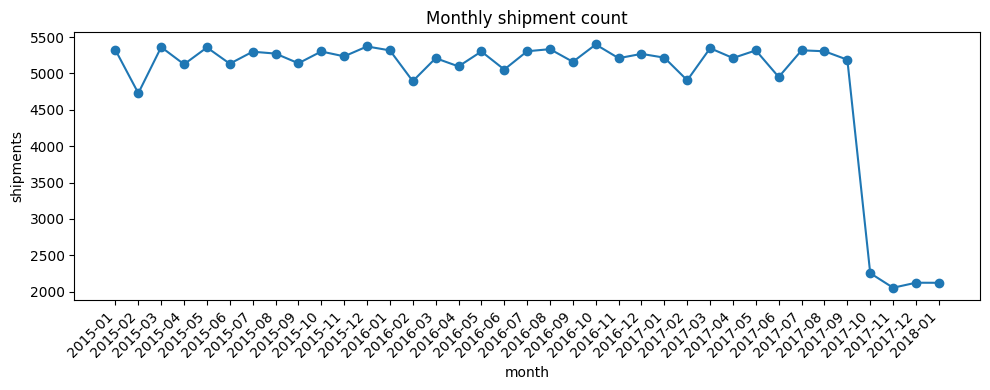

In [25]:
p = monthly.toPandas()

plt.figure(figsize=(10, 4))
plt.plot(p["month"], p["shipment_count"], marker="o")
plt.title("Monthly shipment count")
plt.xlabel("month")
plt.ylabel("shipments")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Q6. ETL pipeline development

In [26]:
out_path = os.path.join(base_path, "etl_output")

ship_etl = df.select(
    "Order Id",
    "Customer Id",
    "Shipping Mode",
    "Delivery Status",
    "Late_delivery_risk",
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Sales",
    "Order Region",
    "Order Country",
    "Order City",
    "order_ts",
    "ship_ts"
).dropna()

ship_etl = ship_etl.withColumn(
    "delay_flag",
    when(col("Late_delivery_risk") == 1, "delayed").otherwise("not_delayed")
).withColumn(
    "delay_days",
    col("Days for shipping (real)") - col("Days for shipment (scheduled)")
)

warehouse_etl = df.groupBy("Department Name").agg(
    count("*").alias("order_count"),
    spark_sum("Order Item Quantity").alias("total_quantity"),
    rnd(spark_sum("Sales"), 2).alias("total_sales"),
    rnd(avg("Sales"), 2).alias("avg_sales"),
    rnd(avg("Late_delivery_risk"), 2).alias("avg_late_risk")
)

tracking_etl = df.select(
    "Order Id",
    "Latitude",
    "Longitude",
    "Order Region",
    "Order Country",
    "Order City",
    "Shipping Mode",
    "Delivery Status",
    "Late_delivery_risk",
    "order_ts",
    "ship_ts"
).dropna()

tracking_etl = tracking_etl.withColumn(
    "tracking_status",
    when(col("Delivery Status") == "Late delivery", "delayed")
    .when(col("Delivery Status") == "Shipping canceled", "cancelled")
    .otherwise("moving_or_completed")
)

In [27]:
ship_etl.write.mode("overwrite").parquet(os.path.join(out_path, "shipments"))
warehouse_etl.write.mode("overwrite").parquet(os.path.join(out_path, "warehouse"))
tracking_etl.write.mode("overwrite").parquet(os.path.join(out_path, "tracking"))

print("shipment etl rows:", ship_etl.count())
print("warehouse etl rows:", warehouse_etl.count())
print("tracking etl rows:", tracking_etl.count())

shipment etl rows: 180519
warehouse etl rows: 11
tracking etl rows: 180519


In [28]:
spark.read.parquet(os.path.join(out_path, "shipments")).select(
    "Order Id", "delay_flag", "delay_days", "Sales"
).show(5)

spark.read.parquet(os.path.join(out_path, "warehouse")).show(5, False)

spark.read.parquet(os.path.join(out_path, "tracking")).select(
    "Order Id", "Latitude", "Longitude", "tracking_status"
).show(5, False)

+--------+-----------+----------+------+
|Order Id| delay_flag|delay_days| Sales|
+--------+-----------+----------+------+
|   77202|not_delayed|        -1|327.75|
|   75939|    delayed|         1|327.75|
|   75938|not_delayed|         0|327.75|
|   75937|not_delayed|        -1|327.75|
|   75936|not_delayed|        -2|327.75|
+--------+-----------+----------+------+
only showing top 5 rows
+---------------+-----------+--------------+-----------+---------+-------------+
|Department Name|order_count|total_quantity|total_sales|avg_sales|avg_late_risk|
+---------------+-----------+--------------+-----------+---------+-------------+
|Golf           |33220      |99297         |4609028.24 |138.74   |0.55         |
|Apparel        |48998      |98181         |7976255.34 |162.79   |0.55         |
|Outdoors       |9686       |26059         |1253351.45 |129.4    |0.55         |
|Fitness        |2479       |6227          |397050.89  |160.17   |0.56         |
|Footwear       |14525      |43400      

## Q7. Machine learning model for delivery delay prediction

In [29]:
ml_df = df.select(
    "Late_delivery_risk",
    "Days for shipment (scheduled)",
    "Sales",
    "Order Item Quantity",
    "Benefit per order",
    "Order Item Profit Ratio",
    "Shipping Mode",
    "Department Name",
    "Market",
    "Type",
    "Order Region",
    "Customer Segment"
).dropna()

cats = [
    "Shipping Mode",
    "Department Name",
    "Market",
    "Type",
    "Order Region",
    "Customer Segment"
]

for c in cats:
    idx = c.replace(" ", "_").lower() + "_idx"
    si = StringIndexer(inputCol=c, outputCol=idx, handleInvalid="keep").fit(ml_df)
    ml_df = si.transform(ml_df)

late_cnt = ml_df.filter(col("Late_delivery_risk") == 1).count()
ok_cnt = ml_df.filter(col("Late_delivery_risk") == 0).count()
w0 = late_cnt / ok_cnt

ml_df = ml_df.withColumn(
    "weight",
    when(col("Late_delivery_risk") == 0, w0).otherwise(1.0)
)

print("late:", late_cnt)
print("not late:", ok_cnt)
print("not late weight:", w0)

late: 98977
not late: 81542
not late weight: 1.2138161928821958


In [30]:
features = [
    "Days for shipment (scheduled)",
    "Sales",
    "Order Item Quantity",
    "Benefit per order",
    "Order Item Profit Ratio",
    "shipping_mode_idx",
    "department_name_idx",
    "market_idx",
    "type_idx",
    "order_region_idx",
    "customer_segment_idx"
]

va = VectorAssembler(inputCols=features, outputCol="features")

data = va.transform(ml_df).select(
    col("Late_delivery_risk").alias("label"),
    "features",
    "weight"
)

train, test = data.randomSplit([0.8, 0.2], seed=42)

print("train rows:", train.count())
print("test rows:", test.count())

train rows: 144353
test rows: 36166


In [31]:
lr = LogisticRegression(maxIter=50, weightCol="weight")
model = lr.fit(train)

pred = model.transform(test)

acc = MulticlassClassificationEvaluator(metricName="accuracy").evaluate(pred)
auc = BinaryClassificationEvaluator(metricName="areaUnderROC").evaluate(pred)

print("accuracy:", acc)
print("auc:", auc)

accuracy: 0.6961510811259194
auc: 0.7122359431342625


In [32]:
pred.groupBy("label", "prediction").count().orderBy("label", "prediction").show()

pred.select("label", "prediction", "probability").show(10, False)

+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0|13306|
|    0|       1.0| 2890|
|    1|       0.0| 8099|
|    1|       1.0|11871|
+-----+----------+-----+

+-----+----------+----------------------------------------+
|label|prediction|probability                             |
+-----+----------+----------------------------------------+
|0    |0.0       |[0.6650927828409136,0.33490721715908645]|
|0    |0.0       |[0.6547883285978677,0.34521167140213227]|
|0    |0.0       |[0.658535725514405,0.341464274485595]   |
|0    |0.0       |[0.6601896695721042,0.33981033042789577]|
|0    |0.0       |[0.6624123675690013,0.33758763243099865]|
|0    |0.0       |[0.663025440686441,0.336974559313559]   |
|0    |0.0       |[0.6638129518058092,0.33618704819419076]|
|0    |0.0       |[0.6640948650974363,0.3359051349025637] |
|0    |0.0       |[0.6646686890183341,0.3353313109816659] |
|0    |0.0       |[0.6646359933610383,0.3353640066389617] |
+-----+----------+-

In [34]:
from pyspark.sql.functions import abs as spark_abs

# model coefficients
coef = [float(x) for x in model.coefficients]

coef_rows = list(zip(features, coef))

coef_df = spark.createDataFrame(
    coef_rows,
    ["feature", "coefficient"]
)

coef_df.orderBy(spark_abs(col("coefficient")).desc()).show(20, False)

+-----------------------------+----------------------+
|feature                      |coefficient           |
+-----------------------------+----------------------+
|shipping_mode_idx            |-2.7907975774545175   |
|Days for shipment (scheduled)|-2.4375536730470233   |
|market_idx                   |0.013686372859410743  |
|Order Item Profit Ratio      |0.012611581551239912  |
|Order Item Quantity          |-0.0024976954538574033|
|order_region_idx             |-0.0024975431804809193|
|type_idx                     |0.002295715303570258  |
|customer_segment_idx         |0.002038287466400149  |
|department_name_idx          |0.0013070372110085269 |
|Benefit per order            |-1.494564294875063E-4 |
|Sales                        |-2.7227712069119826E-5|
+-----------------------------+----------------------+

